# Optimization is the process of adjusting the weights and biases in a neural network to minimize the loss function.

In [ ]:
It happens during training, using backpropagation + gradient descent.

In [ ]:
Every iteration (or epoch), this loop runs:
1. Forward pass → calculate prediction ŷ
2. Compute loss → compare ŷ vs. true y
3. Backward pass → compute gradients (∂L/∂W)
4. Optimization step → update weights W = W - η·∇L


In [ ]:
 Why Optimization Is Needed?
We want our model to learn from data

Learning = minimizing loss
Loss is minimized by finding optimal weights
Weights are tuned via optimization algorithms

Without optimization, your weights never improve — and your model never learns.

In [ ]:
What We Optimize ?
| Component         | What Happens                                       |
| ----------------- | -------------------------------------------------- |
| **Weights (W)**   | Adjusted to reduce the error in prediction         |
| **Biases (b)**    | Shift the output, also learned via gradients       |
| **Loss Function** | Gives the "error" to be minimized (e.g., MSE, BCE) |
| **Activation**    | NOT optimized, but it affects how gradients flow   |
| **Learning Rate** | Controls how big each optimization step is         |


In [ ]:
| Optimizer | Behavior                              | Notes                         |
| --------- | ------------------------------------- | ----------------------------- |
| SGD       | Vanilla gradient descent              | Simple but slower convergence |
| Adam      | Adaptive learning rate                | Most popular and robust       |
| RMSProp   | Scales learning rate using moving avg | Good for RNNs                 |
| Adagrad   | Adapts learning rate per parameter    | Good for sparse data          |


# “Optimization is the engine behind learning.
# It updates model weights to reduce error based on computed gradients.
# Activation functions shape the landscape, but optimization navigates it.”

Training with SGD...
Training with SGD + Momentum...
Training with Adam...
Training with RMSprop...
Training with Adagrad...


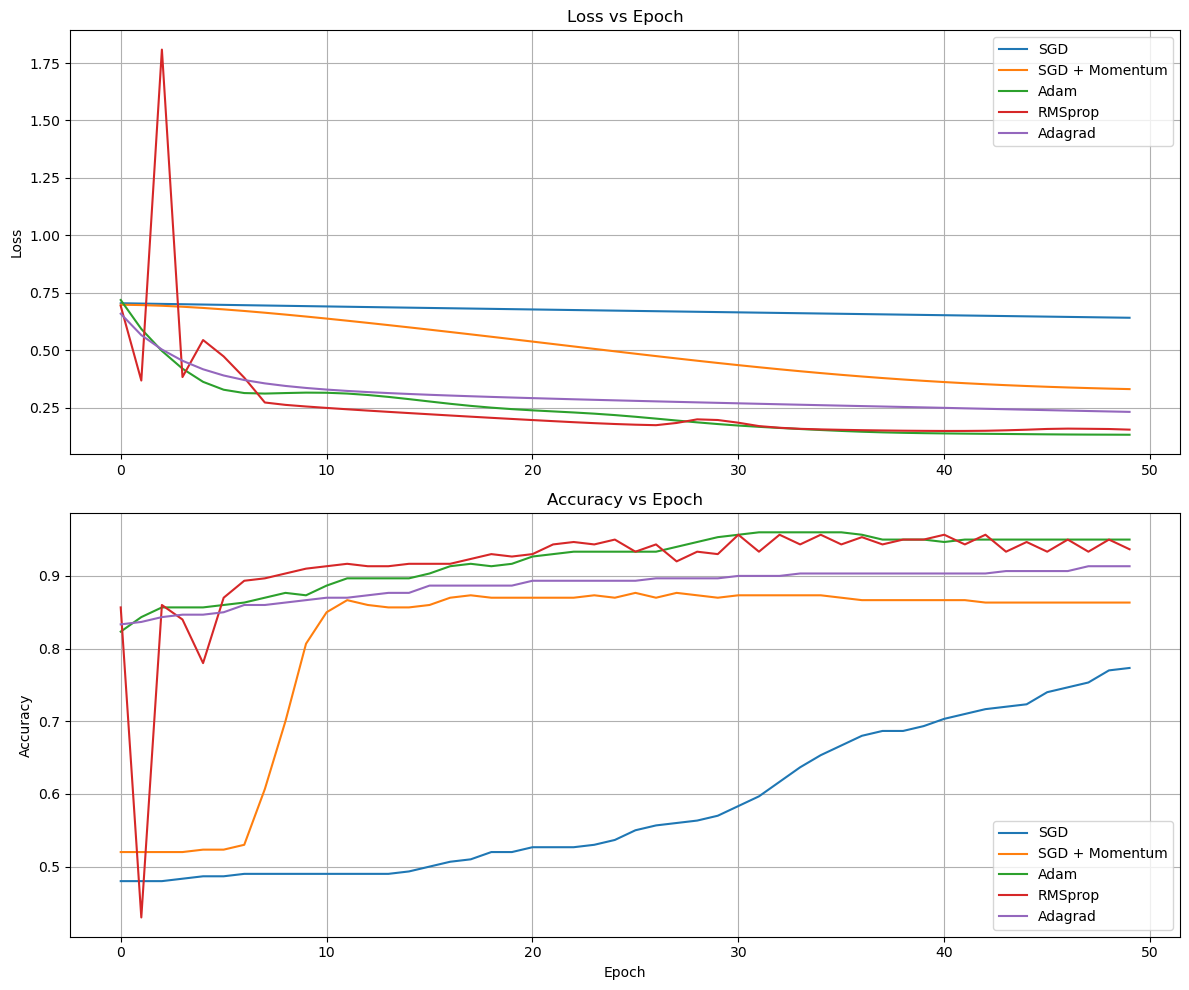

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Data
X, y = make_moons(n_samples=1000, noise=0.25, random_state=42)
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Model
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        
# 🔸 nn.Linear(2, 64)
# Input layer → 2 input features
# First hidden layer → 64 neurons
# This means each of the 64 neurons gets 2 weights + 1 bias

# 🔸 nn.ReLU()
# Applies nonlinearity to the output of the first hidden layer
# 🔸 nn.Linear(64, 64)
# Second hidden layer
# Each of the 64 neurons here takes input from all 64 outputs of the previous layer

# 🔸 nn.ReLU()
# Again, adds nonlinearity
# 🔸 nn.Linear(64, 1)
# Final output layer → 1 neuron

# This neuron takes all 64 outputs from the second hidden layer and produces one value (e.g., for binary classification)

    def forward(self, x):
        return self.net(x)

# Training loop
def train_with_optimizer(optimizer_fn):
    model = Net()
    optimizer = optimizer_fn(model.parameters())
    criterion = nn.BCELoss()
    losses, accs = [], []

    for _ in range(50):
        model.train()
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            y_out = model(X_test)
            acc = ((y_out > 0.5) == y_test).float().mean().item()
        losses.append(loss.item())
        accs.append(acc)

    return losses, accs

# Optimizers to test
optimizers = {
    "SGD": lambda p: torch.optim.SGD(p, lr=0.01),
    "SGD + Momentum": lambda p: torch.optim.SGD(p, lr=0.01, momentum=0.9),
    "Adam": lambda p: torch.optim.Adam(p, lr=0.01),
    "RMSprop": lambda p: torch.optim.RMSprop(p, lr=0.01),
    "Adagrad": lambda p: torch.optim.Adagrad(p, lr=0.01)
}

# Run all optimizers
results = {}
for name, opt_fn in optimizers.items():
    print(f"Training with {name}...")
    results[name] = train_with_optimizer(opt_fn)

# Plot
fig, axs = plt.subplots(2, 1, figsize=(12, 10))
for name, (loss, acc) in results.items():
    axs[0].plot(loss, label=name)
    axs[1].plot(acc, label=name)

axs[0].set_title("Loss vs Epoch")
axs[0].set_ylabel("Loss")
axs[0].legend()
axs[0].grid(True)

axs[1].set_title("Accuracy vs Epoch")
axs[1].set_ylabel("Accuracy")
axs[1].set_xlabel("Epoch")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# Stochastic Gradient Descent (SGD)
Intuition:
Basic idea: “Use the gradient to go downhill on the loss surface.”

 Formula:
θ = θ - η * ∇L(θ)
θ: model weights

η: learning rate

∇L(θ): gradient of the loss with respect to θ

Limitations:
Very sensitive to learning rate

Can oscillate or get stuck in local minima or saddle points

Slow convergence, especially on complex surfaces

In [ ]:
# SGD with Momentum

Intuition:
Imagine a ball rolling down a hill. Momentum smooths out the updates — it remembers the direction and builds speed in low-curvature regions.

Formula:

v = β * v + η * ∇L(θ)
θ = θ - v
β is momentum coefficient (e.g., 0.9)

v is velocity — the moving average of past gradients

 Benefits:
Faster convergence
Reduces oscillations (especially in ravines)
Think: "inertia" in learning

In [ ]:
# RMSProp (Root Mean Square Propagation)

Intuition:
Some parameters change more frequently than others. 
RMSProp scales learning rate adaptively based on recent gradient magnitudes (suppress noisy updates).

Formula:

E[g²] = γ * E[g²] + (1 - γ) * (∇L)²
θ = θ - η / (√(E[g²]) + ε) * ∇L
E[g²]: moving average of squared gradients

Parameters with large gradients get smaller learning rates

 Benefits:
Good for non-stationary loss functions
Common in RNNs, where gradients vary wildly

In [ ]:
# Adagrad

Intuition:
Some weights learn more frequently. Adagrad accumulates past gradient squares and scales learning rate down over time.

Formula:

G += ∇L²
θ = θ - η / (√G + ε) * ∇L
G: sum of squares of gradients for each parameter

Benefits:
Automatically adapts learning rate per parameter
Very good for sparse features

Problem:
Learning rate keeps shrinking → eventually stops learning

In [ ]:
| Optimizer    | Key Idea                      | Fixes...                    |
| ------------ | ----------------------------- | --------------------------- |
| **SGD**      | Pure gradient descent         | Slow learning, oscillations |
| **Momentum** | Add velocity (moving avg)     | Smooths path, faster conv.  |
| **RMSProp**  | Scale by avg of squared grads | Noisy/unstable gradients    |
| **Adagrad**  | Accumulate gradient magnitude | Sparse features             |
| **Adam**     | Momentum + RMSProp            | Adaptive, smooth, fast      |


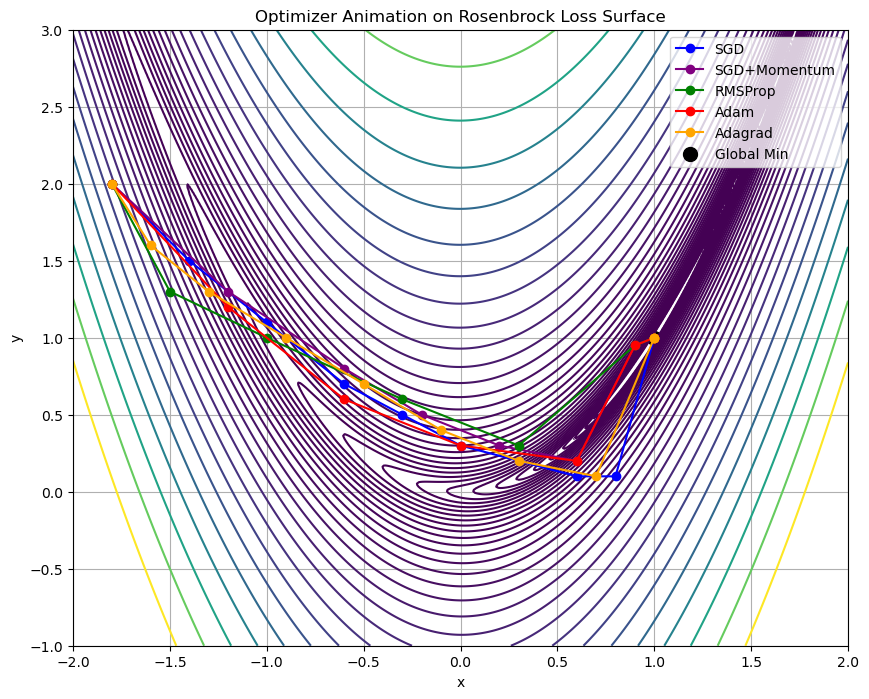

In [10]:
# ANIMATION TO SHOW WHEN THEY SAY OPTIMIZATION? WHAT IT MEANS!


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

def rosenbrock(x, y):
    return (1 - x)**2 + 100 * (y - x**2)**2

x_vals = np.linspace(-2, 2, 400)
y_vals = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x_vals, y_vals)
Z = rosenbrock(X, Y)

paths = {
    "SGD": [(-1.8, 2.0), (-1.4, 1.5), (-1.0, 1.1), (-0.6, 0.7), (-0.3, 0.5), (0.0, 0.3), (0.3, 0.2), (0.6, 0.1), (0.8, 0.1), (1.0, 1.0)],
    "SGD+Momentum": [(-1.8, 2.0), (-1.2, 1.3), (-0.6, 0.8), (-0.2, 0.5), (0.2, 0.3), (0.6, 0.2), (0.9, 0.95), (1.0, 1.0)],
    "RMSProp": [(-1.8, 2.0), (-1.5, 1.3), (-1.0, 1.0), (-0.3, 0.6), (0.3, 0.3), (0.9, 0.95), (1.0, 1.0)],
    "Adam": [(-1.8, 2.0), (-1.2, 1.2), (-0.6, 0.6), (0.0, 0.3), (0.6, 0.2), (0.9, 0.95), (1.0, 1.0)],
    "Adagrad": [(-1.8, 2.0), (-1.6, 1.6), (-1.3, 1.3), (-0.9, 1.0), (-0.5, 0.7), (-0.1, 0.4), (0.3, 0.2), (0.7, 0.1), (1.0, 1.0)]
}

colors = {
    "SGD": "blue",
    "SGD+Momentum": "purple",
    "RMSProp": "green",
    "Adam": "red",
    "Adagrad": "orange"
}

fig, ax = plt.subplots(figsize=(10, 8))
ax.contour(X, Y, Z, levels=np.logspace(-1, 3, 35), cmap='viridis')

lines, dots = {}, {}
for name in paths:
    lines[name], = ax.plot([], [], 'o-', color=colors[name], label=name)
    dots[name], = ax.plot([], [], 'o', color=colors[name])

ax.scatter(1, 1, color='black', s=100, label='Global Min')
ax.set_xlim(-2, 2)
ax.set_ylim(-1, 3)
ax.set_title("Optimizer Animation on Rosenbrock Loss Surface")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
ax.grid(True)

def update(frame):
    for name, path in paths.items():
        if frame < len(path):
            xs, ys = zip(*path[:frame + 1])
            lines[name].set_data(xs, ys)
            dots[name].set_data([path[frame][0]], [path[frame][1]])
    return list(lines.values()) + list(dots.values())

ani = animation.FuncAnimation(fig, update, frames=10, interval=800, blit=True)
ani.save("optimizer_comparison1.gif", writer='pillow', fps=1)


 Visualize how different optimizers move over a 3D loss surface like Rosenbrock. 
 Hope it helps build intuition for how optimizers "walk" toward the minimum
 

The Rosenbrock function is a non-convex function used as a benchmark for optimization algorithms. It's also known as the Banana function because of its curved valley shape.

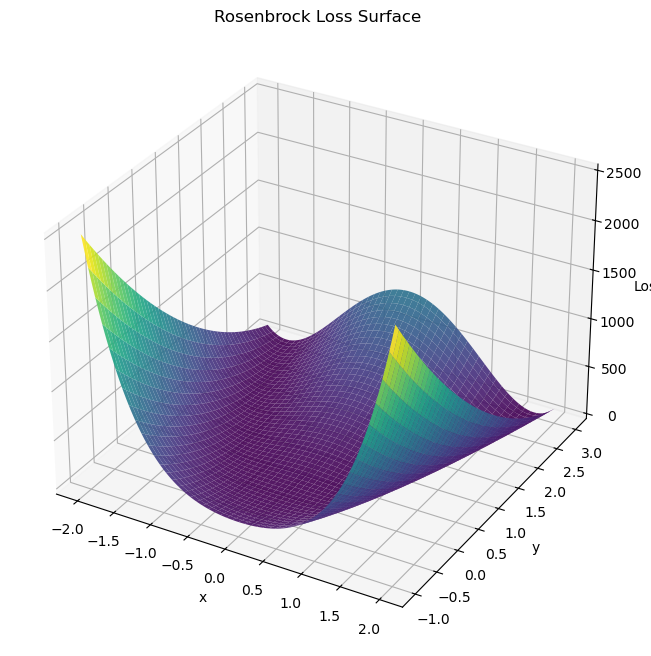

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def rosenbrock(x, y):
    return (1 - x)**2 + 100 * (y - x**2)**2

# Create a meshgrid
x = np.linspace(-2, 2, 400)
y = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x, y)
Z = rosenbrock(X, Y)

# Plot the 3D surface
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.9, edgecolor='none')

ax.set_title("Rosenbrock Loss Surface")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("Loss")
plt.show()


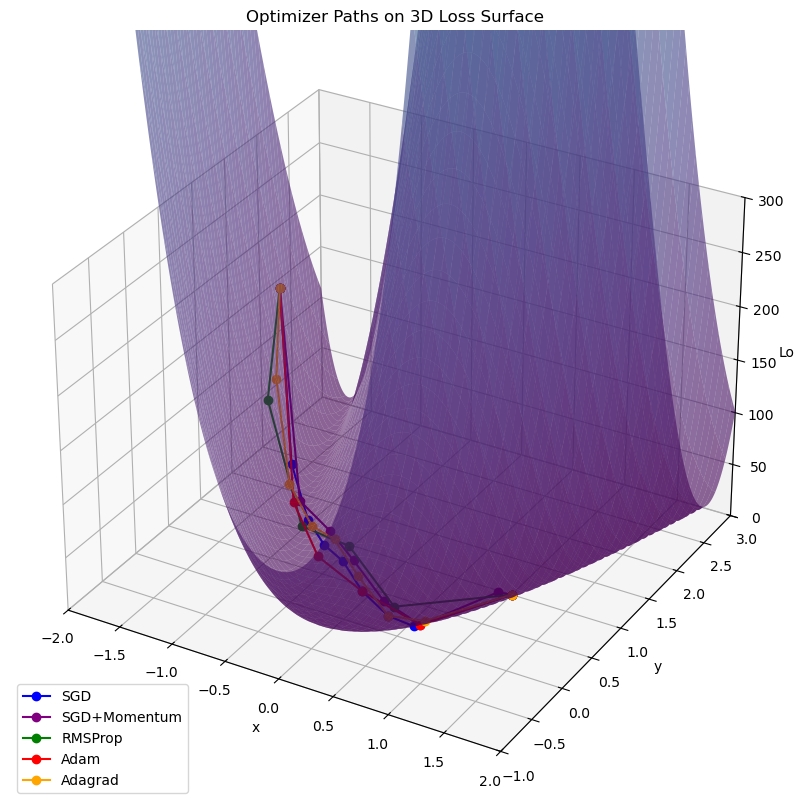

In [16]:
# Just a animation 

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation

def rosenbrock(x, y):
    return (1 - x)**2 + 100 * (y - x**2)**2

x = np.linspace(-2, 2, 400)
y = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x, y)
Z = rosenbrock(X, Y)

optimizer_paths = {
    "SGD": [(-1.8, 2.0), (-1.4, 1.5), (-1.0, 1.1), (-0.6, 0.7), (-0.3, 0.5), (0.0, 0.3), (0.3, 0.2), (0.6, 0.1), (1.0, 1.0)],
    "SGD+Momentum": [(-1.8, 2.0), (-1.2, 1.3), (-0.6, 0.8), (-0.2, 0.5), (0.2, 0.3), (0.6, 0.2), (0.9, 0.95), (1.0, 1.0)],
    "RMSProp": [(-1.8, 2.0), (-1.5, 1.3), (-1.0, 1.0), (-0.3, 0.6), (0.3, 0.3), (1.0, 1.0)],
    "Adam": [(-1.8, 2.0), (-1.2, 1.2), (-0.6, 0.6), (0.0, 0.3), (0.6, 0.2), (1.0, 1.0)],
    "Adagrad": [(-1.8, 2.0), (-1.6, 1.6), (-1.3, 1.3), (-0.9, 1.0), (-0.5, 0.7), (-0.1, 0.4), (0.3, 0.2), (0.7, 0.1), (1.0, 1.0)]
}

colors = {
    "SGD": "blue",
    "SGD+Momentum": "purple",
    "RMSProp": "green",
    "Adam": "red",
    "Adagrad": "orange"
}

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6, edgecolor='none')
ax.set_xlim(-2, 2)
ax.set_ylim(-1, 3)
ax.set_zlim(0, 300)
ax.set_title("Optimizer Paths on 3D Loss Surface")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("Loss")

lines = {}
for name in optimizer_paths:
    lines[name], = ax.plot([], [], [], label=name, color=colors[name], marker='o')

ax.legend()

def update(frame):
    for name, path in optimizer_paths.items():
        if frame < len(path):
            x_vals, y_vals = zip(*path[:frame + 1])
            z_vals = [rosenbrock(x, y) for x, y in path[:frame + 1]]
            lines[name].set_data(x_vals, y_vals)
            lines[name].set_3d_properties(z_vals)
    return list(lines.values())

ani = animation.FuncAnimation(fig, update, frames=10, interval=800, blit=True)
ani.save("optimizer_3d_paths_all.gif", writer='pillow', fps=1)



# Effect of Learning Rate on Optimization

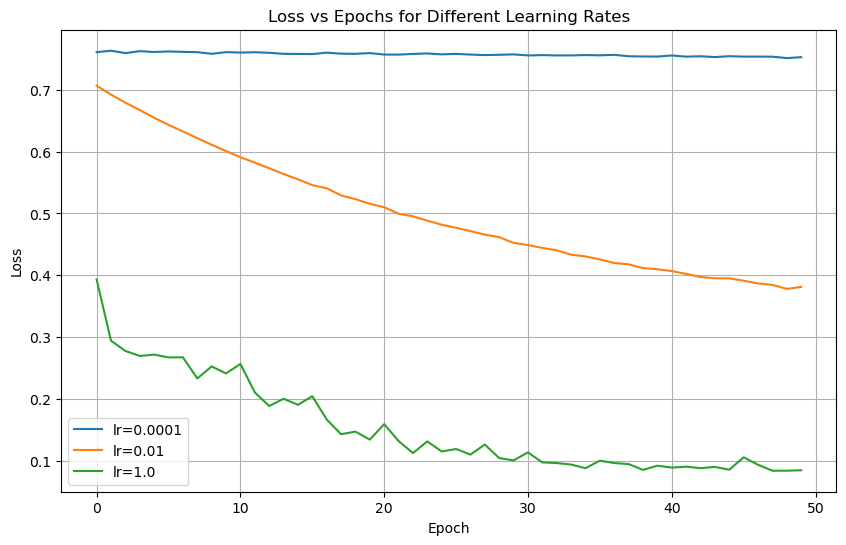

In [17]:
# Loss
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Create synthetic 2D dataset
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
train_ds = TensorDataset(X_train, y_train)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)

# Simple MLP model
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

# Training function
def train_model(lr):
    model = SimpleNN()
    criterion = nn.BCELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    losses = []

    for epoch in range(50):
        total_loss = 0
        for xb, yb in train_dl:
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        losses.append(total_loss / len(train_dl))
    
    return losses

# Train with different learning rates
lrs = [0.0001, 0.01, 1.0]
loss_histories = {lr: train_model(lr) for lr in lrs}

# Plotting
plt.figure(figsize=(10, 6))
for lr, losses in loss_histories.items():
    plt.plot(losses, label=f"lr={lr}")
plt.title("Loss vs Epochs for Different Learning Rates")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig("loss_vs_lr.png")
plt.show()


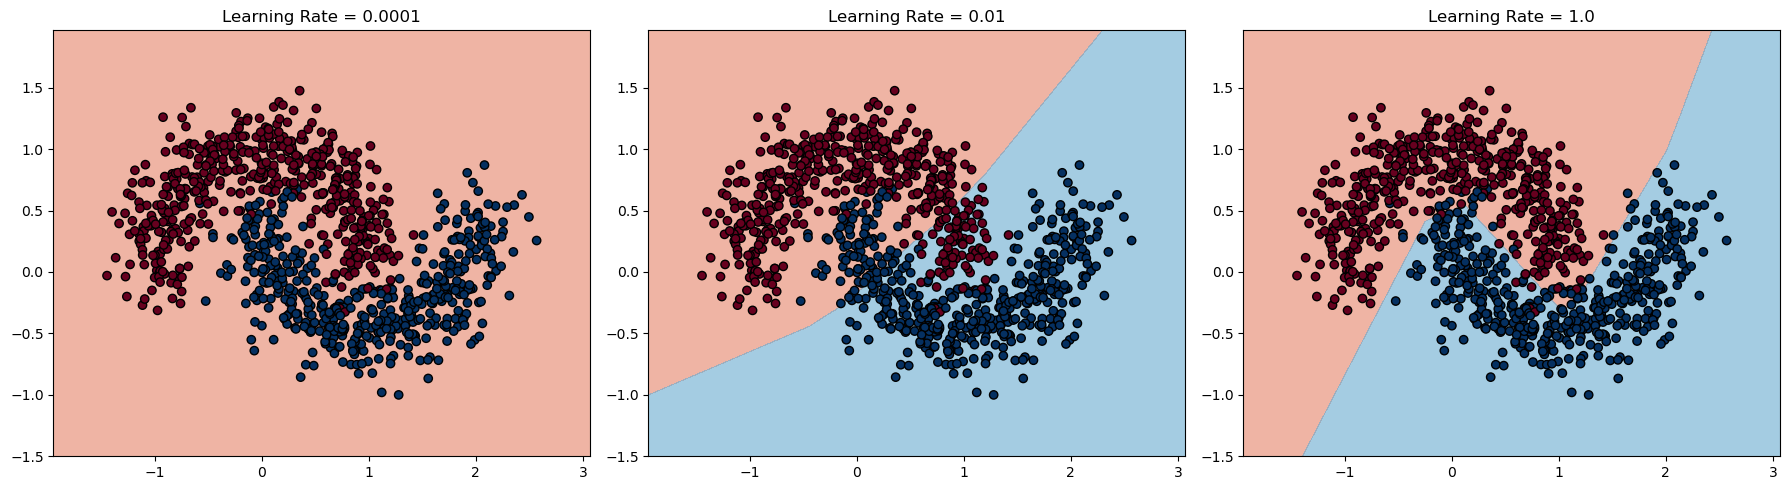

In [20]:
# Decision boundaries 

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Generate synthetic data
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)
train_ds = TensorDataset(X_train, y_train)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)

# Neural network
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

# Training function
def train_model(lr):
    model = SimpleNN()
    criterion = nn.BCELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    for epoch in range(50):
        for xb, yb in train_dl:
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    return model

# Plotting decision boundaries
def plot_decision_boundary(model, X, y, ax, title):
    h = 0.01
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    with torch.no_grad():
        probs = model(grid).reshape(xx.shape)
    ax.contourf(xx, yy, probs, levels=[0, 0.5, 1], cmap=plt.cm.RdBu, alpha=0.6)
    ax.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap=plt.cm.RdBu, edgecolors='k')
    ax.set_title(title)

# Run and visualize
lrs = [0.0001, 0.01, 1.0]
models = [train_model(lr) for lr in lrs]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, lr in enumerate(lrs):
    plot_decision_boundary(models[i], X, y, axes[i], f"Learning Rate = {lr}")
plt.tight_layout()
plt.savefig("decision_boundaries_lr.png")
plt.show()


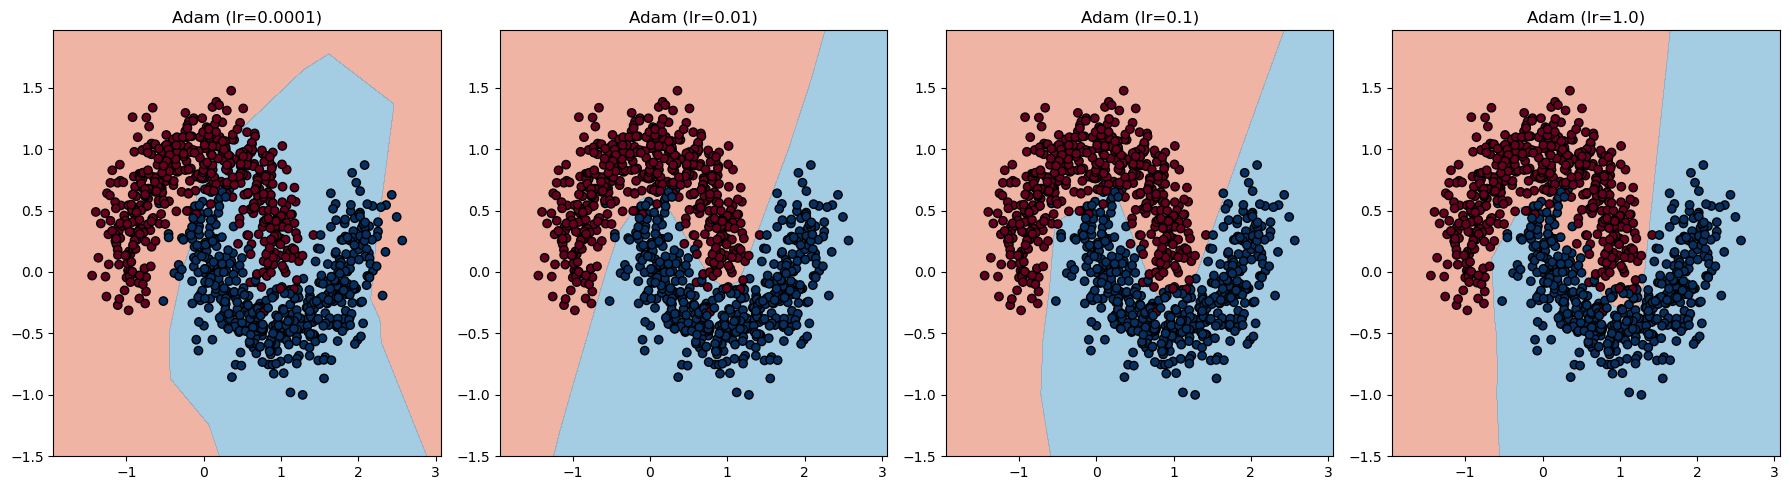

In [22]:
# Optimizers against learning rate

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Dataset
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)
train_ds = TensorDataset(X_train, y_train)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)

# Model
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

# Training function
def train_model(optimizer_name, lr):
    model = SimpleNN()
    criterion = nn.BCELoss()
    if optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr)
    else:
        raise ValueError("Unsupported optimizer")

    for epoch in range(50):
        for xb, yb in train_dl:
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    return model

# Plotting decision boundary
def plot_decision_boundary(model, X, y, ax, title):
    h = 0.01
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    with torch.no_grad():
        probs = model(grid).reshape(xx.shape)
    ax.contourf(xx, yy, probs, levels=[0, 0.5, 1], cmap=plt.cm.RdBu, alpha=0.6)
    ax.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap=plt.cm.RdBu, edgecolors='k')
    ax.set_title(title)

# Different learning rates
learning_rates = [0.0001, 0.01, 0.1, 1.0]
optimizer_name = 'Adam'  # Change to 'SGD' to compare that

models = [train_model(optimizer_name, lr) for lr in learning_rates]

# Plot
fig, axes = plt.subplots(1, len(learning_rates), figsize=(18, 5))
for i, lr in enumerate(learning_rates):
    plot_decision_boundary(models[i], X, y, axes[i], f"{optimizer_name} (lr={lr})")
plt.tight_layout()
plt.savefig("decision_boundary_lr_variation.png")
plt.show()


In [ ]:
Too low → slow convergence.

Too high → diverges or oscillates.

Just right → fast and stable convergence.

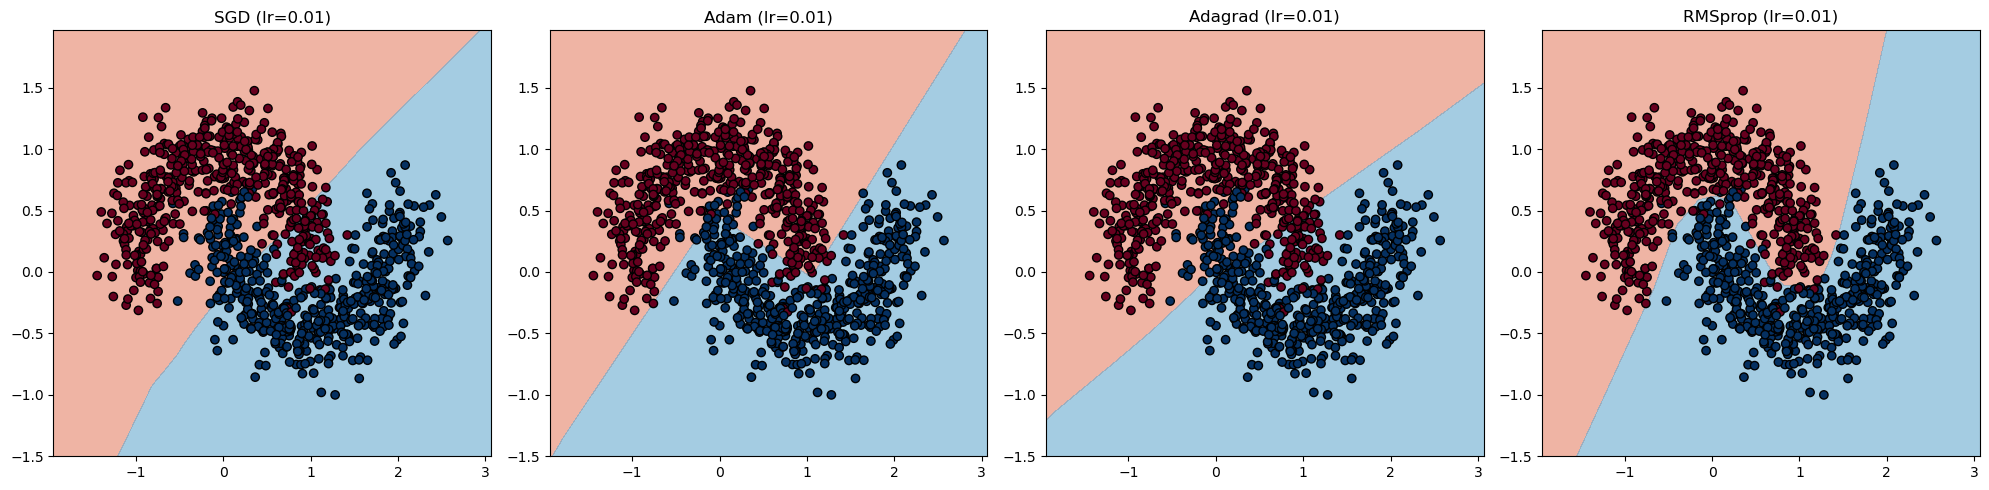

In [23]:
# Acorss different optimizers at fixed LR
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Create dataset
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)
train_ds = TensorDataset(X_train, y_train)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)

# Define model
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

# Training function
def train_model(optimizer_name, lr):
    model = SimpleNN()
    criterion = nn.BCELoss()
    if optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == 'Adagrad':
        optimizer = optim.Adagrad(model.parameters(), lr=lr)
    elif optimizer_name == 'RMSprop':
        optimizer = optim.RMSprop(model.parameters(), lr=lr)
    else:
        raise ValueError("Unsupported optimizer")
    
    for epoch in range(50):
        for xb, yb in train_dl:
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    return model

# Plot decision boundaries
def plot_decision_boundary(model, X, y, ax, title):
    h = 0.01
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    with torch.no_grad():
        probs = model(grid).reshape(xx.shape)
    ax.contourf(xx, yy, probs, levels=[0, 0.5, 1], cmap=plt.cm.RdBu, alpha=0.6)
    ax.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap=plt.cm.RdBu, edgecolors='k')
    ax.set_title(title)

# Optimizers to test
optimizers = ['SGD', 'Adam', 'Adagrad', 'RMSprop']
lr = 0.01
models = [train_model(opt, lr) for opt in optimizers]

# Plot all decision boundaries
fig, axes = plt.subplots(1, len(optimizers), figsize=(20, 5))
for i, opt in enumerate(optimizers):
    plot_decision_boundary(models[i], X, y, axes[i], f"{opt} (lr={lr})")
plt.tight_layout()
plt.savefig("decision_boundaries_optimizers.png")
plt.show()


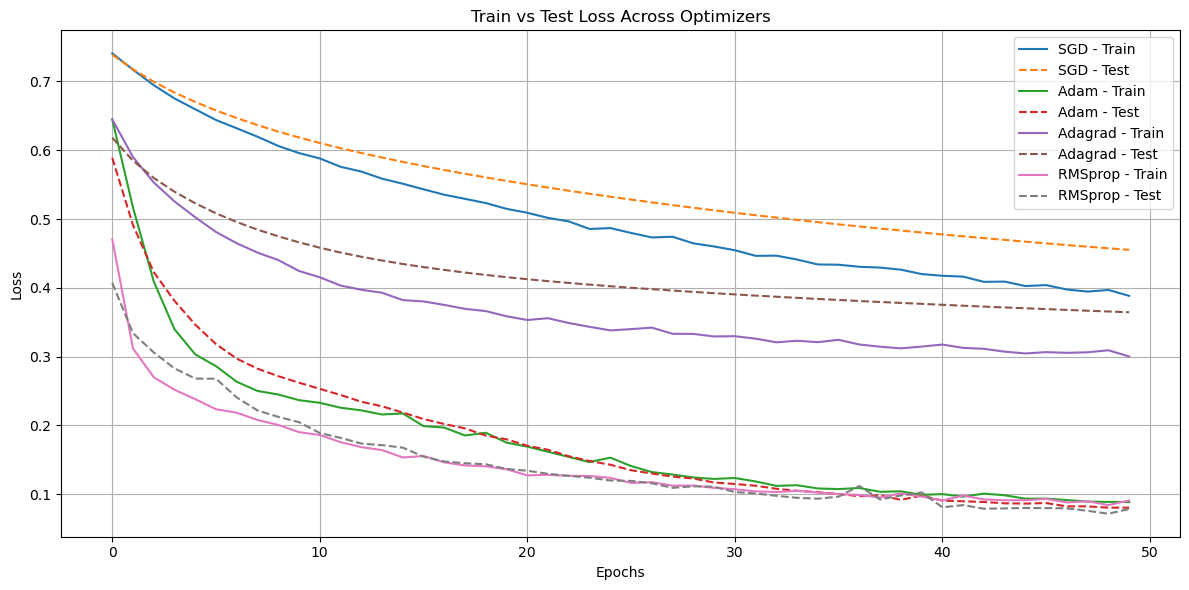

In [25]:
# Training loss vs test loss
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Dataset
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)

# Model
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

# Training loop
def train_and_eval(optimizer_name, lr=0.01):
    model = SimpleNN()
    train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
    test_dl = DataLoader(test_ds, batch_size=64)
    criterion = nn.BCELoss()

    if optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == 'Adagrad':
        optimizer = optim.Adagrad(model.parameters(), lr=lr)
    elif optimizer_name == 'RMSprop':
        optimizer = optim.RMSprop(model.parameters(), lr=lr)

    train_losses, test_losses = [], []

    for _ in range(50):
        model.train()
        total_train_loss = 0
        for xb, yb in train_dl:
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()
        train_losses.append(total_train_loss / len(train_dl))

        model.eval()
        total_test_loss = 0
        with torch.no_grad():
            for xb, yb in test_dl:
                pred = model(xb)
                loss = criterion(pred, yb)
                total_test_loss += loss.item()
        test_losses.append(total_test_loss / len(test_dl))

    return train_losses, test_losses

# Run for different optimizers
optimizers = ['SGD', 'Adam', 'Adagrad', 'RMSprop']
results = {opt: train_and_eval(opt) for opt in optimizers}

# Plot
plt.figure(figsize=(12, 6))
for opt in optimizers:
    train_loss, test_loss = results[opt]
    plt.plot(train_loss, label=f'{opt} - Train')
    plt.plot(test_loss, '--', label=f'{opt} - Test')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Train vs Test Loss Across Optimizers")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
If train loss ↓ but test loss ↑ → overfitting
If both are high → underfitting or bad optimization
Closely matching curves → good generalization